In [1]:
import warnings
warnings.filterwarnings("ignore")
import numba
import joblib
import pandas as pd
import numpy as np

import shap

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
model = joblib.load("../models/lightgbm_model.pkl")

encoder = joblib.load("../models/encoder.pkl")

scaler = joblib.load("../models/scaler.pkl")

feature_names = joblib.load("../models/feature_names.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [3]:
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
X = df.drop(columns=["Churn"])

In [5]:
NUMERICAL_COLS = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

CATEGORICAL_COLS = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

In [6]:
X_num = scaler.transform(
    X[NUMERICAL_COLS]
)

X_cat = encoder.transform(
    X[CATEGORICAL_COLS]
)

X_final = np.hstack(
    (
        X_num,
        X_cat,
    )
)

In [7]:
X_final = pd.DataFrame(
    X_final,
    columns=feature_names,
)

X_final.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,-1.281624,-1.164077,-0.995824,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.441773,0.061666,-0.264803,-0.179831,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-1.240918,-0.367672,-0.961467,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.441773,0.509429,-0.750942,-0.201222,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.441773,-1.240918,0.191470,-0.942379,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [8]:
explainer = shap.TreeExplainer(model)

print("SHAP Explainer Created Successfully!")

SHAP Explainer Created Successfully!


In [9]:
print(X_final.shape)
print(len(feature_names))

(7043, 45)
45


In [10]:
joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

print("SHAP Explainer Saved Successfully!")

SHAP Explainer Saved Successfully!


In [10]:
shap_values = explainer.shap_values(X_final)

print(type(shap_values))

<class 'numpy.ndarray'>


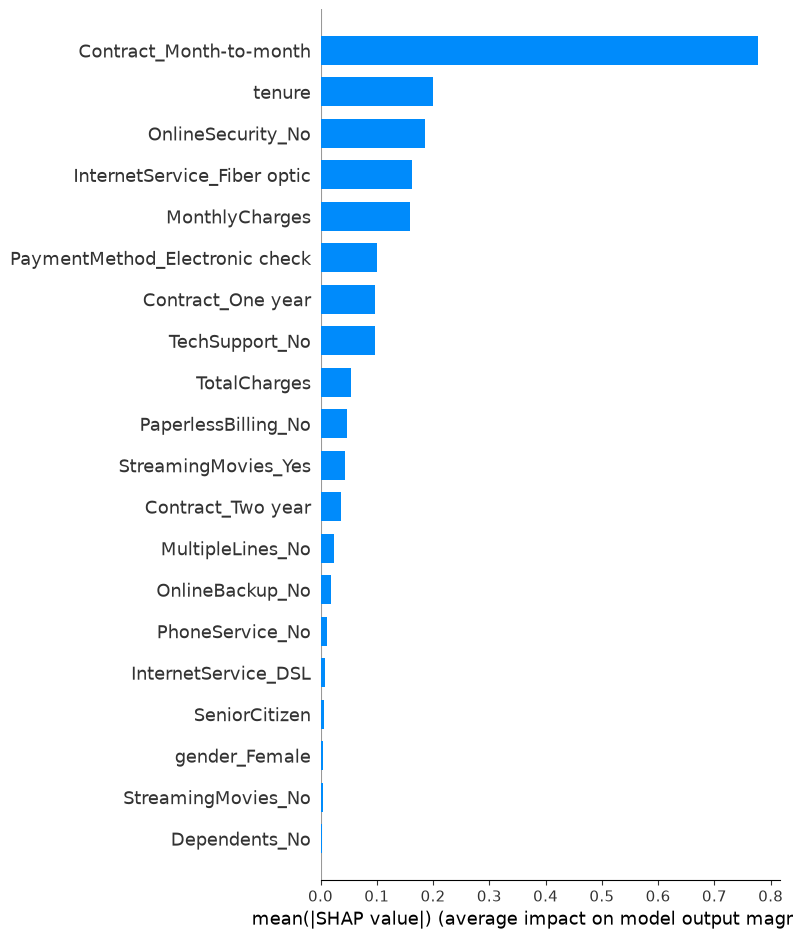

In [11]:
shap.summary_plot(
    shap_values,
    X_final,
    feature_names=feature_names,
    plot_type="bar"
)

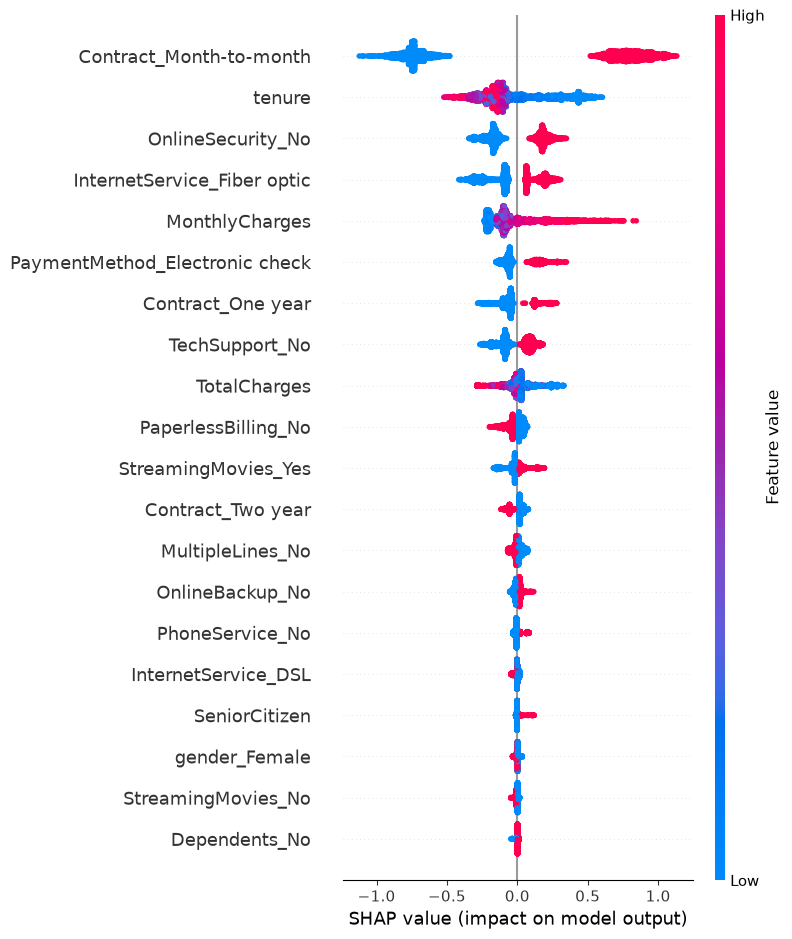

In [12]:
shap.summary_plot(
    shap_values,
    X_final,
    feature_names=feature_names
)

In [13]:
customer_index = 0

print(df.iloc[customer_index])

gender                        Female
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                      No
MultipleLines       No phone service
InternetService                  DSL
OnlineSecurity                    No
OnlineBackup                     Yes
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 29.85
TotalCharges                   29.85
Churn                             No
Name: 0, dtype: object


In [14]:
prediction = model.predict(
    X_final[customer_index].reshape(1, -1)
)

probability = model.predict_proba(
    X_final[customer_index].reshape(1, -1)
)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 1
Probability: [0.42058183 0.57941817]


In [15]:
shap_exp = explainer(X_final)

print(type(shap_exp))

<class 'shap._explanation.Explanation'>


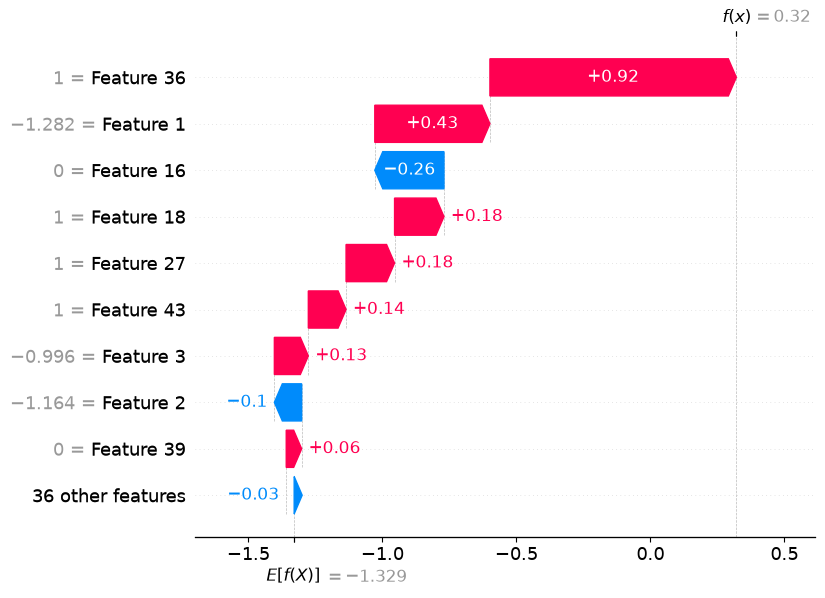

In [16]:
shap.plots.waterfall(
    shap_exp[customer_index]
)

In [17]:
X_shap = pd.DataFrame(
    X_final,
    columns=feature_names
)

In [18]:
X_shap.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,-1.281624,-1.164077,-0.995824,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.441773,0.061666,-0.264803,-0.179831,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-1.240918,-0.367672,-0.961467,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.441773,0.509429,-0.750942,-0.201222,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.441773,-1.240918,0.191470,-0.942379,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [19]:
shap_exp = explainer(X_shap)

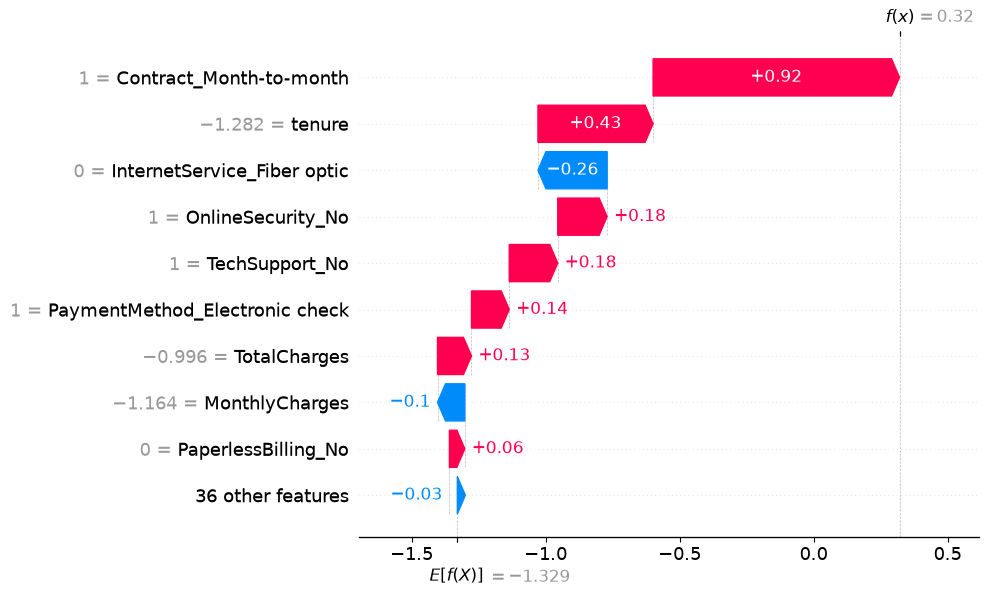

In [20]:
customer_index = 0

shap.plots.waterfall(
    shap_exp[customer_index]
)

In [21]:
%history


import warnings
warnings.filterwarnings("ignore")
import numba
import joblib
import pandas as pd
import numpy as np

import shap

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully!")
model = joblib.load("../models/lightgbm_model.pkl")

encoder = joblib.load("../models/encoder.pkl")

scaler = joblib.load("../models/scaler.pkl")

feature_names = joblib.load("../models/feature_names.pkl")

print("Model Loaded Successfully!")
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})
numerical_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(numerical_cols)

print(categorical_cols)
X_cat = encoder.transform(
    X[categorical_cols]
)
X_num = scaler.transform(
    X[numerical_cols]
)
X_final = np.hstack([

    X_num,

    X_cat

])

print(X_final.